# # Monte Carlo Simulation for MCV1 Forecasts
# This notebook runs Monte Carlo simulations to provide probabilistic forecasts and prediction intervals.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
import warnings
warnings.filterwarnings("ignore")

# Import core forecasting logic
import sys
sys.path.append('.')
from mcv1_forecast.core import train_model, recursive_forecast, COUNTRIES, TARGET

# ## Load Data and Train Base Model

In [2]:
# Load data
df_raw = pd.read_csv(r"D:\Home\Desktop\mcv1_final\backend\vaccine_data.csv")
future_demo_df = pd.read_csv(r"D:\Home\Desktop\mcv1_final\backend\future_demographics.csv")

# Train baseline model
model, df_engineered, feature_cols, dummy_cols = train_model(df_raw)

TimeSeries CV MAE Scores: [12.7446751  16.97363143 23.12675389]
Average CV MAE: 17.615


# ## Monte Carlo Engine

In [3]:
class MonteCarloEngine:
    def __init__(self, model, df_engineered, feature_cols, dummy_cols,
                 n_simulations=500, random_seed=42):
        self.model = model
        self.df_engineered = df_engineered
        self.feature_cols = feature_cols
        self.dummy_cols = dummy_cols
        self.n_simulations = n_simulations
        self.rng = np.random.RandomState(random_seed)
        self.country_scale = {}
        self.pooled_residuals = np.array([])
        
        # Pool MAD-standardized residuals across countries
        self._prepare_residual_pool()
        
    def _prepare_residual_pool(self):
        """Compute MAD-standardized residuals per country and pool them."""
        # Expand backtest window from 2020 to 2010 to get more residuals
        backtest_results = recursive_forecast(
            self.df_engineered, self.model, self.feature_cols,
            self.dummy_cols, 2010, TARGET
        )
        backtest_results = backtest_results.dropna(subset=['Actual', 'Predicted'])
        backtest_results['Residual'] = backtest_results['Actual'] - backtest_results['Predicted']
        
        all_standardized = []
        for country in COUNTRIES:
            res = backtest_results[backtest_results['Country'] == country]['Residual'].values
            if len(res) > 1:
                mad = median_abs_deviation(res, scale='normal')
                if mad == 0:
                    mad = max(np.max(np.abs(res)), 1e-6)
                med = np.median(res)
                self.country_scale[country] = mad
                z = (res - med) / mad
                all_standardized.append(z)
            else:
                self.country_scale[country] = 5.0
        
        if len(all_standardized) > 0:
            self.pooled_residuals = np.concatenate(all_standardized)
        else:
            self.pooled_residuals = np.array([0.0])

    def _generate_noise(self, n, country):
        """Generate noise using a fitted t-distribution (robust for small samples)."""
        from scipy.stats import t as t_dist
        
        pool = self.pooled_residuals
        if len(pool) < 2:
            return self.rng.normal(0, 1, size=n) * self.country_scale[country]
            
        # Fit t-distribution to pooled standardized residuals
        df_t, loc_t, scale_t = t_dist.fit(pool)
        
        # Draw from the fitted t-distribution
        samples = t_dist.rvs(df_t, loc=loc_t, scale=scale_t, size=n, 
                              random_state=self.rng)
        return samples * self.country_scale[country]

    def perturb_demographics(self, demo_df):
        """Apply correlated perturbations to demographic inputs."""
        perturbed_df = demo_df.copy()
        
        # Ensure 'Year' is an integer column for reliable indexing
        years = perturbed_df['Year'].unique()
        base_year = min(years) if len(years) > 0 else 2025
        
        for idx, row in perturbed_df.iterrows():
            year_val = row['Year']
            # Scale uncertainty with forecast horizon (grows 15% per year)
            year_idx = year_val - base_year
            horizon_scale = 1.0 + 0.15 * year_idx
            
            births_mult = self.rng.normal(1.0, 0.05 * horizon_scale)
            imr_mult = self.rng.normal(1.0, 0.10 * horizon_scale)
            
            perturbed_df.at[idx, 'Births (thousands)'] *= births_mult
            perturbed_df.at[idx, 'Pop_Age_0(In Thousands)'] *= births_mult
            perturbed_df.at[idx, 'Infant Mortality Rate (infant deaths per 1,000 live births)'] *= imr_mult
            perturbed_df.at[idx, 'Under-Five Mortality (deaths under age 5 per 1,000 live births)'] *= imr_mult
            
        return perturbed_df

    def run_simulations(self, future_demo_df):
        """Run N simulations for all countries."""
        all_results = []
        
        print(f"Running {self.n_simulations} simulations...")
        for sim_id in range(self.n_simulations):
            if sim_id % 100 == 0:
                print(f"  Simulation {sim_id}/{self.n_simulations}")
                
            # 1. Perturb demographics
            sim_demo_df = self.perturb_demographics(future_demo_df)
            
            # 2. Run deterministic recursive forecast with perturbed demographics
            sim_pred = recursive_forecast(
                self.df_engineered, self.model, self.feature_cols,
                self.dummy_cols, 2025, TARGET, sim_demo_df
            )
            
            # 3. Add residual noise via t-distribution
            for country in COUNTRIES:
                country_mask = sim_pred['Country'] == country
                n_years = country_mask.sum()
                if n_years > 0:
                    noise = self._generate_noise(n_years, country)
                    
                    # Apply dynamic ceiling
                    # Use df_raw from the global scope which contains the historical data
                    last_actual = df_raw[df_raw['Country'] == country][TARGET].iloc[-1]
                    upper_bound = last_actual * 2.0  # Allow up to 2x the last observed value
                    
                    sim_pred.loc[country_mask, 'Predicted'] += noise
                    sim_pred.loc[country_mask, 'Predicted'] = sim_pred.loc[
                        country_mask, 'Predicted'
                    ].clip(lower=0, upper=upper_bound)
                    
            sim_pred['Simulation_ID'] = sim_id
            all_results.append(sim_pred)
            
        return pd.concat(all_results, ignore_index=True)

    def compute_percentiles(self, sim_results):
        """Aggregate simulation results into percentile bands."""
        percentiles = [5, 10, 25, 50, 75, 90, 95]
        
        def pct_func(p):
            return lambda x: np.percentile(x, p)
            
        agg_funcs = {f'P{p}': pct_func(p) for p in percentiles}
        agg_funcs['Mean'] = 'mean'
        
        grouped = sim_results.groupby(['Country', 'Year'])['Predicted'].agg(
            **agg_funcs
        ).reset_index()
        return grouped



# ## Run Simulations

In [4]:
engine = MonteCarloEngine(model, df_engineered, feature_cols, dummy_cols, n_simulations=500)
sim_results = engine.run_simulations(future_demo_df)
percentiles_df = engine.compute_percentiles(sim_results)



--- Walk-forward retraining for year 2010 ---
TimeSeries CV MAE Scores: [14.56940703  8.30346375 30.27104923]
Average CV MAE: 17.715

--- Walk-forward retraining for year 2011 ---
TimeSeries CV MAE Scores: [16.27097224 17.07456903 15.20183526]
Average CV MAE: 16.182

--- Walk-forward retraining for year 2012 ---
TimeSeries CV MAE Scores: [18.61137066  7.22301652 10.4698752 ]
Average CV MAE: 12.101

--- Walk-forward retraining for year 2013 ---
TimeSeries CV MAE Scores: [19.76933283  6.95557118 11.94395642]
Average CV MAE: 12.890

--- Walk-forward retraining for year 2014 ---
TimeSeries CV MAE Scores: [18.75137068 16.31275828 16.44667835]
Average CV MAE: 17.170

--- Walk-forward retraining for year 2015 ---
TimeSeries CV MAE Scores: [19.14997018 24.20699385 12.75041194]
Average CV MAE: 18.702

--- Walk-forward retraining for year 2016 ---
TimeSeries CV MAE Scores: [19.68934642 20.44443623 26.24089537]
Average CV MAE: 22.125

--- Walk-forward retraining for year 2017 ---
TimeSeries CV M

# ## Visualizations

In [7]:
def plot_fan_chart(percentiles_df, hist_df, country):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Use only recent history (last 10 years) for cleaner visuals
    country_hist = hist_df[(hist_df['Country'] == country) & (hist_df['Year'] >= 2015)]
    ax.plot(country_hist['Year'], country_hist[TARGET], 'ko-', 
            markersize=5, linewidth=2, label='Historical', zorder=5)
    
    country_pct = percentiles_df[percentiles_df['Country'] == country]
    years = country_pct['Year']
    
    # Smooth connection to last historical point
    last_hist_year = country_hist['Year'].max()
    last_hist_val = country_hist[TARGET].iloc[-1]
    years_plot = np.insert(years.values, 0, last_hist_year)
    
    p5 = np.insert(country_pct['P5'].values, 0, last_hist_val)
    p10 = np.insert(country_pct['P10'].values, 0, last_hist_val)
    p25 = np.insert(country_pct['P25'].values, 0, last_hist_val)
    p50 = np.insert(country_pct['P50'].values, 0, last_hist_val)
    p75 = np.insert(country_pct['P75'].values, 0, last_hist_val)
    p90 = np.insert(country_pct['P90'].values, 0, last_hist_val)
    p95 = np.insert(country_pct['P95'].values, 0, last_hist_val)
    
    # Multiple gradient bands
    ax.fill_between(years_plot, p5, p95, color='#3498db', alpha=0.08, label='90% CI')
    ax.fill_between(years_plot, p10, p90, color='#3498db', alpha=0.15, label='80% CI')
    ax.fill_between(years_plot, p25, p75, color='#3498db', alpha=0.30, label='50% CI')
    ax.plot(years_plot, p50, color='#2980b9', linewidth=2.5, label='Median (P50)')
    
    # Dynamic Y-axis padding
    all_vals = np.concatenate([country_hist[TARGET].values, p5, p95])
    y_min = min(all_vals) * 0.85
    y_max = max(all_vals) * 1.10
    ax.set_ylim(y_min, y_max)
    
    ax.set_title(f"Monte Carlo MCV1 Forecast — {country}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Year")
    ax.set_ylabel("MCV1 Target (thousands)")
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


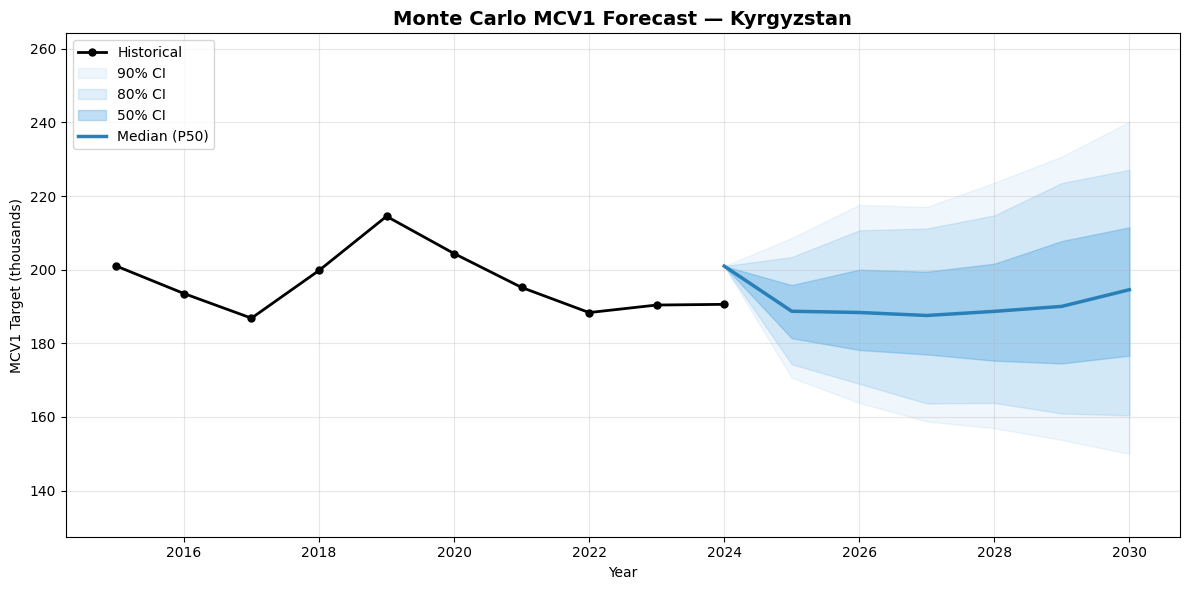

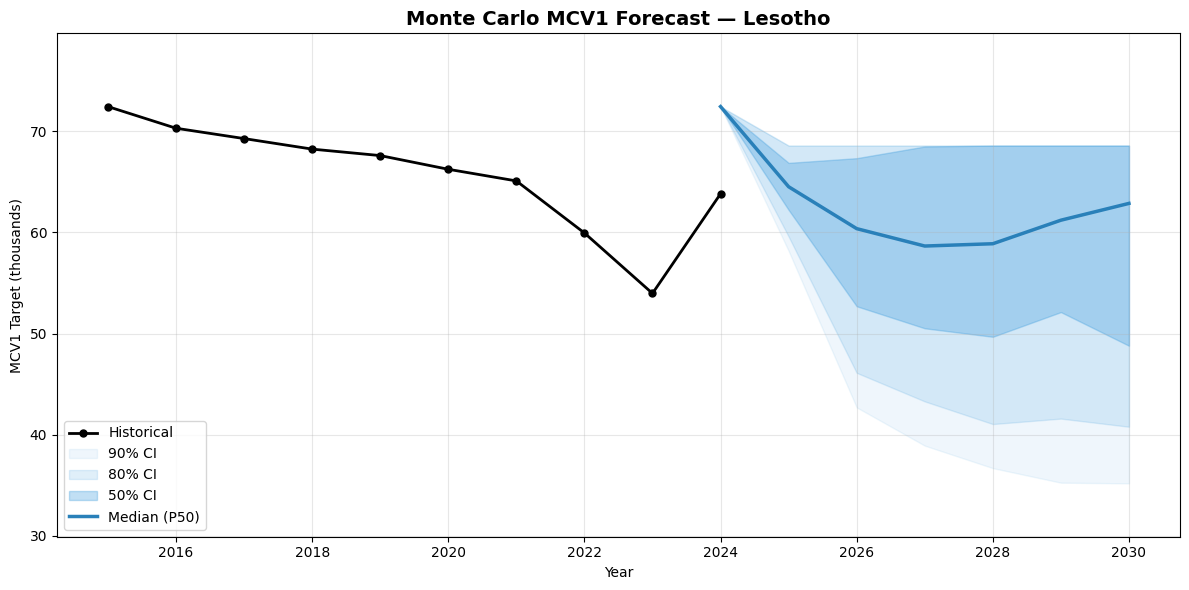

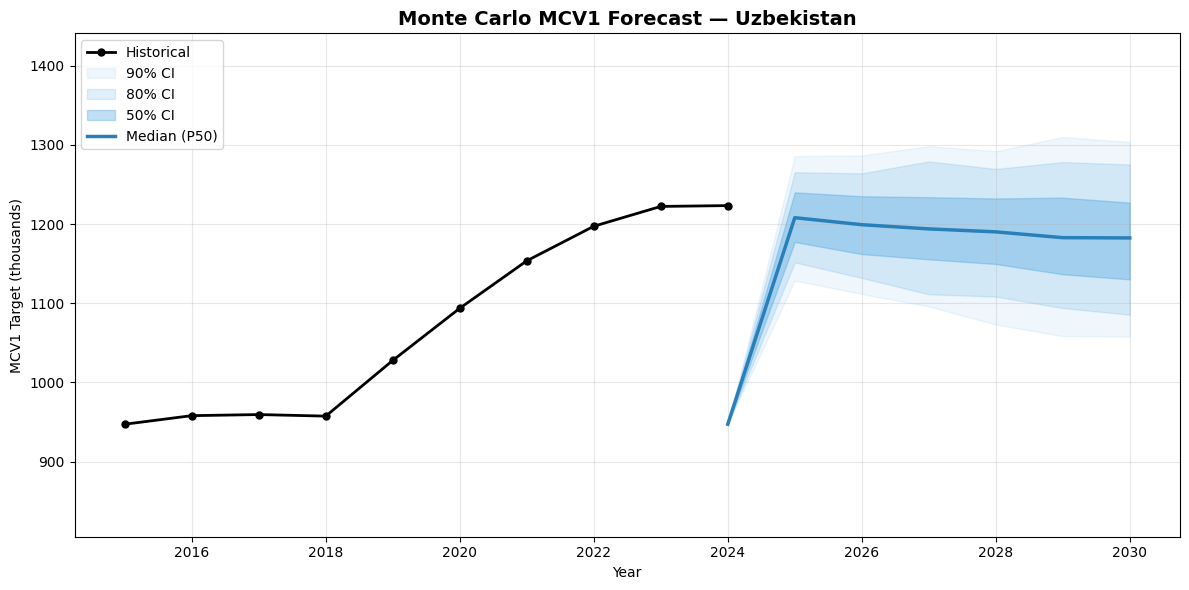

Saved mc_percentiles.csv


In [8]:
for country in COUNTRIES:
    plot_fan_chart(percentiles_df, df_raw, country)

# Save percentiles to CSV for dashboard
percentiles_df.to_csv("mc_percentiles.csv", index=False)
print("Saved mc_percentiles.csv")
